![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

# Vision-OCR-Structured-LLM

Calls a John Snow Labs **jsl-llms** endpoint.

## Endpoint setup

1. In RunPod, create a new Template (or "Deploy" with a custom image).
2. Set Container Image to johnsnowlabs/jsl-llms.
3. Set Container Start Command to --model Vision-OCR-Structured-LLM --port 8080.
4. Add the environment variable SPARK_NLP_LICENSE=<your key>.
5. Under Expose HTTP Ports, add 8080.
6. If the image is private on Docker Hub, add your registry credentials under the template's registry auth settings.

## Configuration

In [1]:
BASE_URL = "https://lpmhgdzd6tvwrm-8080.proxy.runpod.net/"
MODEL = "Vision-OCR-Structured-LLM"
IMAGE_PATH = "../mixed_formats/prescription.jpg"

In [2]:
import base64
import re

import matplotlib.pyplot as plt
import requests
from IPython.display import Image

## Input image

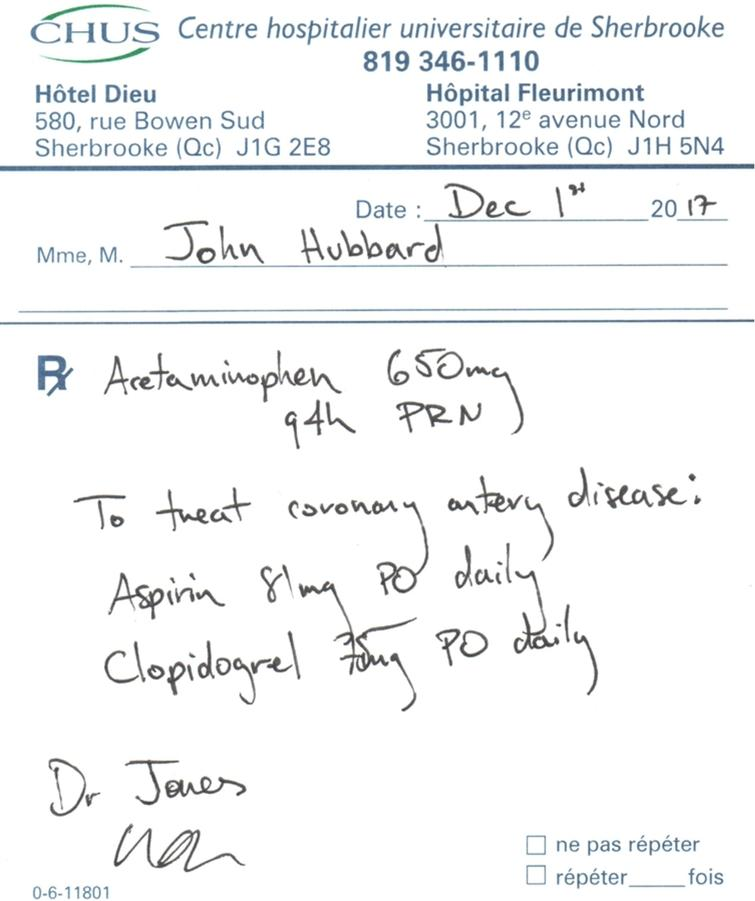

In [3]:
Image(IMAGE_PATH, width=450)

In [4]:
with open(IMAGE_PATH, "rb") as f:
    image_url = "data:image/jpeg;base64," + base64.b64encode(f.read()).decode("utf-8")

## JSON

In [5]:
payload = {
    "model": MODEL,
    "messages": [{"role": "user", "content": [
        {"type": "text", "text": "Extract the information in this prescription as JSON."},
        {"type": "image_url", "image_url": {"url": image_url}},
    ]}],
    "temperature": 0.0,
    "max_tokens": 2048,
}
response = requests.post(f"{BASE_URL.rstrip('/')}/v1/chat/completions", json=payload, timeout=600)
response.raise_for_status()
print(response.json()["choices"][0]["message"]["content"])

```json
{
  "prescriber": {
    "name": "Dr Jones",
    "signature": "signature"
  },
  "patient": {
    "name": "John Hubbard",
    "address": "Mme, M."
  },
  "date": "Dec 1st 2017",
  "prescription": [
    {
      "drug": "Aretaminophen",
      "dosage": "650mg",
      "frequency": "9th PRN",
      "notes": "To treat coronary artery disease;"
    },
    {
      "drug": "Aspirin",
      "dosage": "81mg",
      "route": "PO daily"
    },
    {
      "drug": "Clopidogrel",
      "dosage": "75mg",
      "route": "PO daily"
    }
  ],
  "instructions": {
    "repeat": false,
    "times": 0
  }
}
```
